In [355]:
import h5py
import time
import pandas as pd
from tqdm import tqdm
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from pathlib import Path
from joblib import Parallel, delayed
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import FormatStrFormatter

# custom functions
import load_data
import LFP
import plotting
import graph

In [2]:
def get_coherence(ch1,ch2):
    
    with h5py.File(h5_path, 'r') as f:
        dset = f['wavelet_coeffs']  # access dataset by name
        sig1 = dset[ch1,:] 
        sig2 = dset[ch2,:] 
    
    n_trials = sig1.shape[0]
    SXX = np.zeros(sig1.shape)
    SYY = np.zeros(sig1.shape)
    SXY = np.zeros(sig1.shape,dtype=np.complex64)
    
    for trial in range(n_trials):
        xf = sig1[trial,:]
        yf = sig2[trial,:]
        SXX[trial,:], SYY[trial,:], SXY[trial,:] = LFP.cross_spectrum(xf,yf)
    
    first_step = df.step.values==0
    first_step_df = df[df.step==0]
    tele_idx = first_step_df.use_tele.values
    
    cross_spectrum = np.abs(SXY)**2
    
    idx = (df.step.values==0) & (df.use_tele.values)
    tele_PXY = cross_spectrum[idx,:,:].mean(axis=0)
    tele_coh = np.abs(SXY[idx,:].mean(axis=0)) / np.sqrt(SXX[idx,:].mean(axis=0)) / np.sqrt(SYY[idx,:].mean(axis=0))
    
    idx = (df.step.values==0) & (~df.use_tele.values)
    non_tele_PXY = cross_spectrum[idx,:,:].mean(axis=0)
    non_tele_coh = np.abs(SXY[idx,:].mean(axis=0)) / np.sqrt(SXX[idx,:].mean(axis=0)) / np.sqrt(SYY[idx,:].mean(axis=0))

    return tele_PXY, tele_coh, non_tele_PXY, non_tele_coh

In [75]:
date = '031723'
window = [-500,1000]
epoch = 'node_on'

nwbfile = load_data.load_nwbfile('Bart',date) 
df = nwbfile.intervals[epoch].to_dataframe().query('(step==0) & (trialerror==0)')
df = graph.append_use_tele(df)
df['saved_steps'] = df.spatial_distance-df.graph_distance

results = load_data.epoch_aligned_band(date,df,window)

#### label if a trial has planning saccades or not

In [ ]:
choice_df = nwbfile.intervals['action_on'].to_dataframe().query('(step==0) & (trialerror==0)')
df['RT'] = choice_df.t_on.values - df.t_on.values
fix_df = nwbfile.intervals['fixations'].to_dataframe()
planning = fix_df[(fix_df.duration>50) & (fix_df.duration<300) & (fix_df.active_prob<0.2)]

plan_or_not = np.zeros(len(df))

for ii, trial in enumerate(df.trial.values):
    after_node_on = planning.query('trial==@trial').start_time.values>df.query('trial==@trial').t_on.values
    before_choice_on = planning.query('trial==@trial').stop_time.values<choice_df.query('trial==@trial').t_on.values
    plan_or_not[ii] = np.any(after_node_on & before_choice_on)

df['plan'] = plan_or_not==1

In [134]:
epoch = 'node_on'
flash_df = nwbfile.intervals[epoch].to_dataframe().query('trialerror==1')
flash_results = load_data.epoch_aligned_band(date,flash_df,window)

In [111]:
tele_idx = df.use_tele.values
tele = results['power'][tele_idx,:,:].mean(axis=0)
non_tele = results['power'][~tele_idx,:,:].mean(axis=0)
X = np.hstack([non_tele,tele]).T

In [342]:
results['power'].shape

(492, 192, 1500)

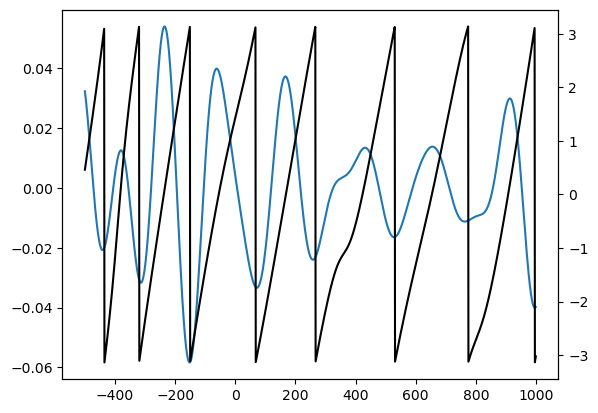

In [351]:
trial = 0
ch = 0
plt.close('all')
fig, ax = plt.subplots()
ax.plot(time,results['band'][trial,ch,:])
ax2 = ax.twinx()
ax2.plot(time,results['phase'][trial,ch,:],color='k')

#### spike phase

In [ ]:
# get LFP and spike timing for a session
timestamps, lfpData = load_data.load_LFP(date)
lfpFile = h5py.File(
    f'D:/Teleworld/bart_I/raw/spikes/Bart_TeleWorld_v13_{date}-spikes.mat', 'r'
)
spikeTable = lfpFile['spikeTable'][:len(timestamps), :]

# get unit information
unit_params = {"drift": 2, "min_fr": 1}
unitNames = nwbfile.units.to_dataframe()
unit_idx =  np.where((unitNames.group == "good") & (unitNames.drift <= unit_params["drift"]) & (unitNames.fr >= unit_params["min_fr"]))[0]

aligned_spikes = epoch_aligned_spike(date,df,window)

In [ ]:
tuning = pd.read_pickle("D:/SingleNeuron/Tuning first step.pkl")
session = tuning[tuning.Session=='031723']
tele_neurons = session[np.isin(session.max_node.values,[0,15])]

In [395]:
tele_neurons = session[np.isin(session.max_node.values,[0,15])]
tele_neurons.unitNumber

,Animal,Session,unitNumber,unitNames,channelNumbers,unitOnChannel,probe,firingRate,date,region,...,spatial_ftest_pval,generic_target_pval,generic_value_pval,value,spatial_reg,max_node,sig_diff_node_all,sig_diff_node,generic_target,generic_value
5,Bart,031723,7.0,S01_SPK004_001,4.0,1.0,1.0,2.814105,31723.0,OFC,...,"[0.47099373699418057, 0.24659965871149958, 0.1...","[[0.46615489484506345, 0.4578556672841513, 0.4...","[[0.11766522091262943, 0.0001446448234342368, ...",False,True,15.0,"[4, 6, 5, 5, 6, 7, 5, 4, 2, 8, 9, 13, 14, 14, ...",14,True,False
13,Bart,031723,16.0,S01_SPK007_001,7.0,1.0,1.0,6.427162,31723.0,OFC,...,"[0.2387471173058866, 0.29656587539241197, 0.33...","[[0.3470446657839602, 0.33595651437034335, 0.3...","[[0.0665141814859016, 0.06346544106483676, 0.0...",False,False,15.0,"[4, 7, 4, 4, 3, 9, 9, 10, 8, 9, 9, 10, 5, 5, 7...",5,False,False
36,Bart,031723,40.0,S01_SPK044_001,44.0,1.0,2.0,19.924203,31723.0,OFC,...,"[0.17890162817008148, 0.2780400023548899, 0.21...","[[0.2044955577806813, 0.19841300182257338, 0.2...","[[0.00034011112093856877, 0.3191488622620703, ...",True,True,0.0,"[4, 4, 5, 0, 0, 1, 9, 14, 15, 11, 8, 9, 10, 11...",11,True,False
76,Bart,031723,82.0,S01_SPK081_001,81.0,1.0,3.0,5.625803,31723.0,OFC,...,"[0.7045505773942411, 0.7412432208160655, 0.402...","[[0.7342398971190147, 0.6876723251513823, 0.73...","[[0.49509455665478674, 0.7045930494503638, 0.0...",False,False,0.0,"[3, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 2, 0, ...",2,False,False
9,Bart,031723,110.0,S01_SPK107_001,107.0,1.0,4.0,2.759866,31723.0,HPC,...,"[0.7651838120516825, 0.7981234030660223, 0.617...","[[0.7907272101075224, 0.7657423407434514, 0.85...","[[0.9007430228332685, 0.32601290876553735, 0.7...",False,False,0.0,"[2, 2, 1, 1, 1, 1, 2, 3, 1, 4, 5, 3, 12, 6, 5,...",5,False,False
20,Bart,031723,122.0,S01_SPK122_002,122.0,2.0,4.0,3.201734,31723.0,HPC,...,"[0.13016078523289365, 0.627209425248205, 0.892...","[[0.18679509321644772, 0.1508611179645034, 0.1...","[[0.29109091934569886, 0.0044435537417789606, ...",False,False,15.0,"[8, 4, 0, 0, 0, 0, 0, 1, 2, 2, 3, 8, 8, 12, 8,...",3,False,False
41,Bart,031723,158.0,S01_SPK151_002,151.0,2.0,5.0,2.492006,31723.0,HPC,...,"[0.3373038715780021, 0.6490634524432873, 0.552...","[[0.3147805723469578, 0.281129023204185, 0.532...","[[0.002476044295663171, 0.4791434629176382, 0....",False,True,15.0,"[0, 0, 1, 0, 7, 5, 0, 0, 1, 2, 9, 11, 12, 13, ...",9,True,False
45,Bart,031723,166.0,S01_SPK161_001,161.0,1.0,6.0,9.771064,31723.0,HPC,...,"[0.7330628938114294, 0.9175204886905366, 0.652...","[[0.6740816383016882, 0.6698720821595907, 0.68...","[[0.12616690091693483, 0.17861175386637773, 0....",False,True,15.0,"[0, 0, 0, 1, 0, 0, 0, 4, 6, 5, 11, 8, 9, 12, 9...",11,True,False
50,Bart,031723,171.0,S01_SPK164_002,164.0,2.0,6.0,18.591381,31723.0,HPC,...,"[0.9708615183690023, 0.9094718585398396, 0.745...","[[0.9669279653454861, 0.9557547744890708, 0.99...","[[0.0022734212095611994, 0.49101162183598646, ...",False,False,15.0,"[0, 0, 1, 4, 1, 0, 8, 14, 4, 0, 7, 1, 0, 0, 0,...",7,True,False
51,Bart,031723,172.0,S01_SPK164_003,164.0,3.0,6.0,2.473125,31723.0,HPC,...,"[0.18527741827625333, 0.42167673636590297, 0.5...","[[0.22173468584712785, 0.20829267997340994, 0....","[[0.1187201449075116, 0.5978264285928556, 0.29...",True,False,15.0,"[5, 4, 1, 2, 2, 0, 0, 2, 2, 5, 4, 2, 2, 1, 1, ...",4,False,False


In [404]:
kk = 4
unit = int(tele_neurons.unitNumber.values[kk])
channel = int(tele_neurons.channelNumbers.values[kk] - 1)     # channel numbers are 1-192, for indexing -1

In [417]:
from scipy.ndimage import convolve1d

In [419]:
sigma = 50
gx = np.arange(-3*sigma, 3*sigma)
gaussian = np.exp(-(gx/sigma)**2/2)/(sigma*np.sqrt(2*np.pi))

In [426]:
tele_neurons.sig_diff_node.values[kk]

np.int64(5)

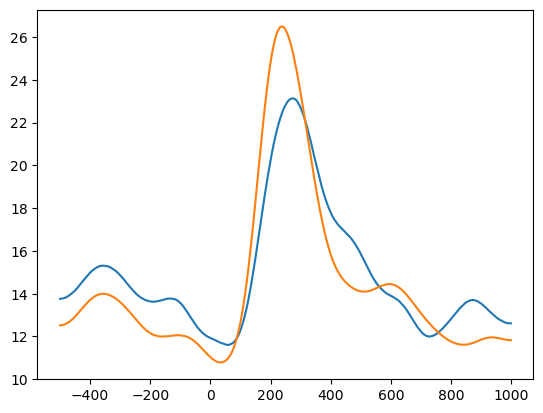

In [423]:
plt.close('all')

meanFR = aligned_spikes[np.where(df.use_tele.values),unit,:].mean(axis=(0,1))
sdf = convolve1d(meanFR, gaussian, axis=0) * 1000
plt.plot(np.arange(-500,1000),sdf)

meanFR = aligned_spikes[np.where(~df.use_tele.values),unit,:].mean(axis=(0,1))
sdf = convolve1d(meanFR, gaussian, axis=0) * 1000
plt.plot(np.arange(-500,1000),sdf)

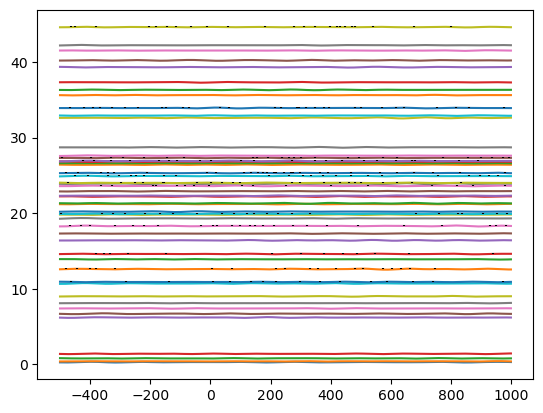

In [410]:
plt.close('all')
for trial in np.where(df.use_tele.values)[0]:
    plt.plot(np.arange(-500,1000),results['band'][trial,channel,:]+trial*0.1)
    plt.vlines(np.where(aligned_spikes[trial,unit,:])[0]-500,0.05+trial*0.1,0.08+trial*0.1,color='k')

In [379]:
def epoch_aligned_spike(date,df,window):

    timestamps, lfpData = load_data.load_LFP(date)
    lfpFile = h5py.File(
        f'D:/Teleworld/bart_I/raw/spikes/Bart_TeleWorld_v13_{date}-spikes.mat', 'r'
    )
    spikeTable = lfpFile['spikeTable'][:len(timestamps), :]
    
    # get unit information
    unit_params = {"drift": 2, "min_fr": 1}
    unitNames = nwbfile.units.to_dataframe()
    unit_idx =  np.where((unitNames.group == "good") & (unitNames.drift <= unit_params["drift"]) & (unitNames.fr >= unit_params["min_fr"]))[0]

    nunits = len(unitNames)
    aligned_spikes = np.zeros((len(df),nunits,window[1]-window[0]))

    
    for ii in range(len(df)):

        on = df.iloc[ii].t_on.astype(float)
        idx = (timestamps>on+window[0]) & (timestamps<on+window[1])
        aligned_spikes[ii,:,:] = spikeTable[idx, :].T

    
    return aligned_spikes

#### planning saccade & theta

In [283]:
# get saccade time
planning_saccade = planning.t_on.values
choice_saccade = choice_df.t_on.values

In [286]:
timestamps, lfpData = load_data.load_LFP(date)
ds = load_data.BandpassLFP("D:/Theta/Session_%s_theta.h5" % date)

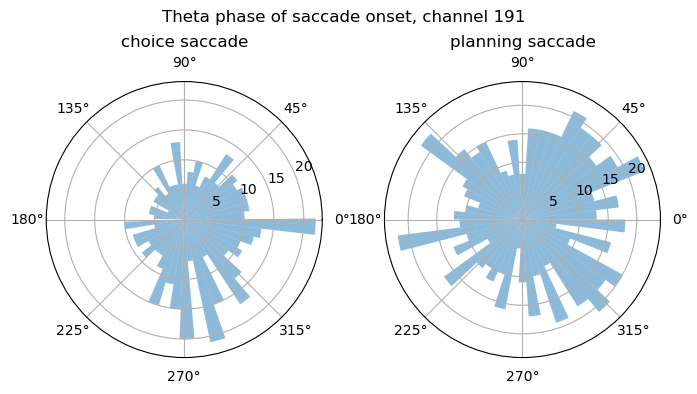

In [322]:
for channel in range(192):
    
    choice_saccade_timeidx = np.isin(timestamps.astype(int),choice_saccade)
    choice_saccade_phase = ds.get_phase(choice_saccade_timeidx,channel)
    
    planning_saccade_timeidx = np.isin(timestamps.astype(int),planning_saccade)
    planning_saccade_phase = ds.get_phase(planning_saccade_timeidx,channel)

    plt.close('all')
    fig = plt.figure(figsize=(8,4))
    axes = [
        fig.add_subplot(1, 2, 1, projection='polar'),
        fig.add_subplot(1, 2, 2, projection='polar')
    ]
    
    # Plot polar histogram
    axes[0].hist(choice_saccade_phase,bins=50, alpha=0.5)
    axes[0].set_title('choice saccade')
    
    axes[1].hist(planning_saccade_phase,bins=50, alpha=0.5)
    axes[1].set_title('planning saccade')
    
    fig.subplots_adjust(top=0.8)
    plt.suptitle(f'Theta phase of saccade onset, channel {channel}')
    plt.savefig(f'D:/Theta/Session_{date}/phase/Theta phase of saccade onset channel {channel}.png')

In [271]:
df.groupby(['plan','use_tele']).count()

start_time  stop_time  trial  step  trialerror  nsteps  start  \
plan  use_tele                                                                  
False False            316        316    316   316         316     316    316   
      True              37         37     37    37          37      37     37   
True  False            127        127    127   127         127     127    127   
      True              12         12     12    12          12      12     12   

                target  block  blocktrialnumber  ...  t_on  graph_distance  \
plan  use_tele                                   ...                         
False False        316    316               316  ...   316             316   
      True          37     37                37  ...    37              37   
True  False        127    127               127  ...   127             127   
      True          12     12                12  ...    12              12   

                spatial_distance  window_size  nodes  timeseries  0to15  \
plan  use_tele                                                            
False False                  316          316    316         316    316   
      True                    37           37     37          37     37   
True  False                  127          127    127         127    127   
      True                    12           12     12          12     12   

                15to0  saved_steps   RT  
plan  use_tele                           
False False       316          316  316  
      True         37           37   37  
True  False       127          127  127  
      True         12           12   12  

[4 rows x 21 columns]

2 4
6 10
7 11
19 27
20 30
25 37
26 38
27 40
34 50
39 57
40 60
51 76


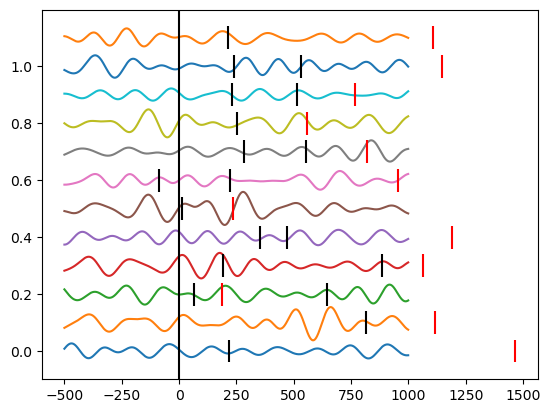

In [275]:
tele_plan_indices = np.where((df.plan) & (~df.use_tele))[0][:12]

plt.close('all')
# plt.figure(figsize=(6,12))
count = 0 
for ii in tele_plan_indices:
    
    trial = df.iloc[ii].trial
    saccade_onset = planning.query('trial==@trial').start_time.values - df.query('trial==@trial').t_on.values
    saccade_onset = saccade_onset[(saccade_onset>-500)&(saccade_onset<1000)]
    
    plt.plot(time,results['band'][ii,99,:]+count*0.1)
    plt.vlines(saccade_onset,-0.04+count*0.1,0.04+count*0.1,color='k')
    plt.vlines(df.iloc[ii].RT,-0.04+count*0.1,0.04+count*0.1,color='r')

    print(ii,trial)

    count=count+1

plt.axvline(0,color='k')

In [ ]:
plt.close('all')
fig, axes = plt.subplots(1,2, figsize=(8,4),sharey=True)

plotting.plot_mean_sem(time, results['power'][idx & tele_idx,:,:].mean(axis=0)[:96,:],axes[0],'g','plan')
plotting.plot_mean_sem(time, results['power'][~idx & tele_idx,:,:].mean(axis=0)[:96,:],axes[0],'g','no plan',ls='--')

#### instantaneous power PCA

In [ ]:
def get_null(n_rep,n_time=1500,n_components=5):

    np.random.seed(42)
    
    pca = make_pipeline(
        StandardScaler(),   # z-score per channel
        PCA(n_components=n_components)
    )

    ofc_pca = np.zeros((n_rep,n_time*2,n_components))
    hpc_pca = np.zeros((n_rep,n_time*2,n_components))
    
    for ii in range(n_rep):
        
        perm_idx = np.random.permutation(tele_idx)

        tele = results['power'][perm_idx,:,:].mean(axis=0)
        non_tele = results['power'][~perm_idx,:,:].mean(axis=0)

        X = np.hstack([non_tele,tele]).T

        ofc_pca[ii,:] = pca.fit_transform(X[:,:96])
        hpc_pca[ii,:] = pca.fit_transform(X[:,96:])

    return ofc_pca, hpc_pca

ofc_pca, hpc_pca = get_null(1000)

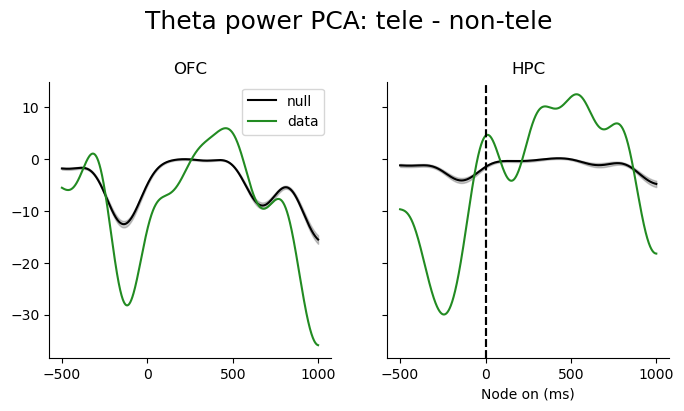

In [144]:
# PCA

X = np.hstack([non_tele,tele]).T

plt.close('all')
fig, axes = plt.subplots(1,2, figsize=(8,4),sharey=True)

plotting.plot_mean_sem(time,ofc_pca[:,1500:,0] - ofc_pca[:,:1500,0],0,axes[0],'k','null')
X_pca = pca.fit_transform(X[:,:96])
axes[0].plot(time,X_pca[1500:,0] - X_pca[:1500,0],label='data',color='forestgreen')
axes[0].set_title('OFC')
axes[1].axvline(0,color='k',ls='--')
axes[1].set_xlabel('Node on (ms)')

plotting.plot_mean_sem(time,hpc_pca[:,1500:,0] - hpc_pca[:,:1500,0],0,axes[1],'k','null')
X_pca = pca.fit_transform(X[:,96:])
axes[1].plot(time,X_pca[1500:,0] - X_pca[:1500,0],label='data',color='forestgreen')
axes[1].set_title('HPC')
axes[1].axvline(0,color='k',ls='--')
axes[1].set_xlabel('Node on (ms)')

sns.despine()
fig.subplots_adjust(top=0.8)
axes[0].legend()
plt.suptitle('Theta power PCA: tele - non-tele',fontsize=18)
plt.savefig(f'D:/Theta/Session_{date}/hilbert_power/Session {date} theta power PCA.png')

#### tele & planning interaction - natrually RT

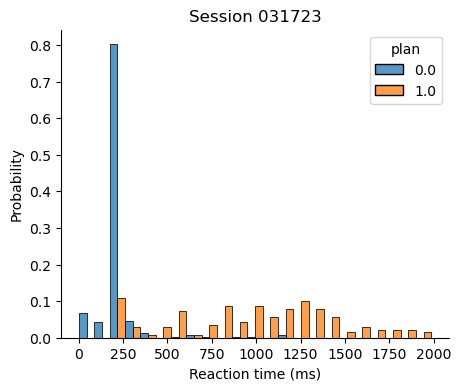

In [210]:
plt.close('all')
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='RT',hue='plan',stat='probability',common_norm=False,multiple='dodge')
plt.title(f'Session {date}')
plt.xlabel('Reaction time (ms)')
sns.despine()
plt.savefig(f'D:/Theta/Session_{date}/hilbert_power/Session {date} RT on planning.png')

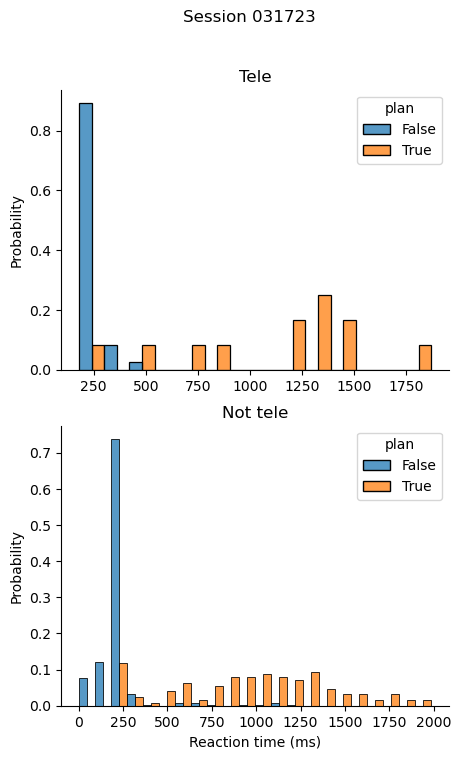

In [281]:
plt.close('all')
fig, axes = plt.subplots(2,1,figsize=(5,8))
sns.histplot(data=df.query('use_tele'),x='RT',hue='plan',stat='probability',common_norm=False,multiple='dodge',ax=axes[0])
sns.histplot(data=df.query('~use_tele'),x='RT',hue='plan',stat='probability',common_norm=False,multiple='dodge',ax=axes[1])

axes[0].set_xlabel('')
axes[1].set_xlabel('Reaction time (ms)')

axes[0].set_title('Tele')
axes[1].set_title('Not tele')

plt.suptitle(f'Session {date}')
sns.despine()
plt.savefig(f'D:/Theta/Session_{date}/hilbert_power/Session {date} RT on planning and tele.png')

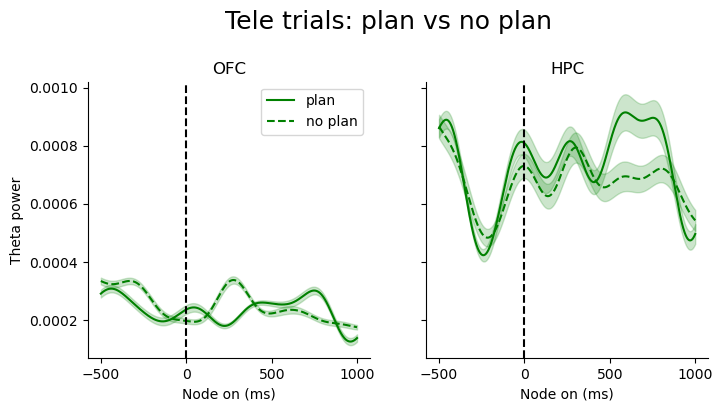

In [220]:
# plan vs non-plan

idx = plan_or_not==1

plt.close('all')
fig, axes = plt.subplots(1,2, figsize=(8,4),sharey=True)

plotting.plot_mean_sem(time, results['power'][idx & tele_idx,:,:].mean(axis=0)[:96,:],axes[0],'g','plan')
plotting.plot_mean_sem(time, results['power'][~idx & tele_idx,:,:].mean(axis=0)[:96,:],axes[0],'g','no plan',ls='--')

axes[0].set_title('OFC')
axes[0].axvline(0,color='k',ls='--')
axes[0].set_xlabel('Node on (ms)')
axes[0].set_ylabel('Theta power')

plotting.plot_mean_sem(time,results['power'][idx & tele_idx,:,:].mean(axis=0)[96:,:],axes[1],'g','')
plotting.plot_mean_sem(time,results['power'][~idx & tele_idx,:,:].mean(axis=0)[96:,:],axes[1],'g','',ls='--')

axes[1].set_title('HPC')
axes[1].axvline(0,color='k',ls='--')
axes[1].set_xlabel('Node on (ms)')

sns.despine()
fig.subplots_adjust(top=0.8)
axes[0].legend()
plt.suptitle('Tele trials: plan vs no plan',fontsize=18)
plt.savefig(f'D:/Theta/Session_{date}/hilbert_power/Session {date} theta power all channels average tele trials plan or not.png')

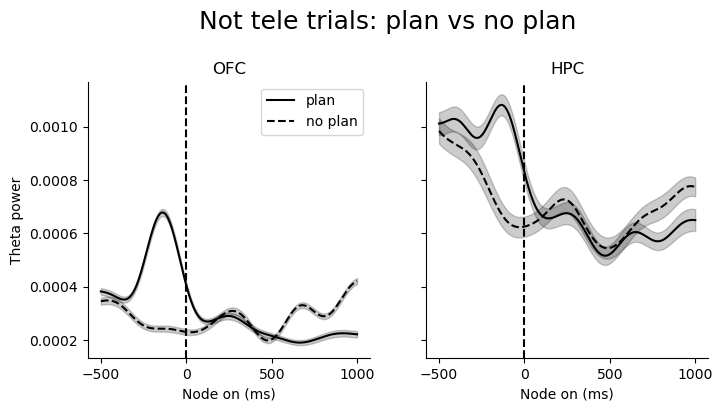

In [221]:
# plan vs non-plan

idx = plan_or_not==1

plt.close('all')
fig, axes = plt.subplots(1,2, figsize=(8,4),sharey=True)

plotting.plot_mean_sem(time, results['power'][idx & ~tele_idx,:,:].mean(axis=0)[:96,:],axes[0],'k','plan')
plotting.plot_mean_sem(time, results['power'][~idx & ~tele_idx,:,:].mean(axis=0)[:96,:],axes[0],'k','no plan',ls='--')

axes[0].set_title('OFC')
axes[0].axvline(0,color='k',ls='--')
axes[0].set_xlabel('Node on (ms)')
axes[0].set_ylabel('Theta power')

plotting.plot_mean_sem(time,results['power'][idx & ~tele_idx,:,:].mean(axis=0)[96:,:],axes[1],'k','')
plotting.plot_mean_sem(time,results['power'][~idx & ~tele_idx,:,:].mean(axis=0)[96:,:],axes[1],'k','',ls='--')

axes[1].set_title('HPC')
axes[1].axvline(0,color='k',ls='--')
axes[1].set_xlabel('Node on (ms)')

sns.despine()
fig.subplots_adjust(top=0.8)
axes[0].legend()
plt.suptitle('Not tele trials: plan vs no plan',fontsize=18)
plt.savefig(f'D:/Theta/Session_{date}/hilbert_power/Session {date} theta power all channels average not tele trials plan or not.png')

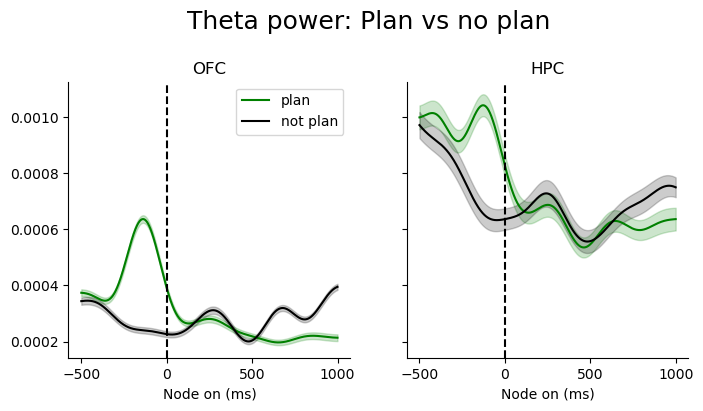

In [217]:
# plan vs non-plan

idx = plan_or_not==1

plt.close('all')
fig, axes = plt.subplots(1,2, figsize=(8,4),sharey=True)

plotting.plot_mean_sem(time, results['power'][idx,:,:].mean(axis=0)[:96,:],axes[0],'g','plan')
plotting.plot_mean_sem(time, results['power'][~idx,:,:].mean(axis=0)[:96,:],axes[0],'k','not plan')
axes[0].set_title('OFC')
axes[0].axvline(0,color='k',ls='--')
axes[0].set_xlabel('Node on (ms)')

plotting.plot_mean_sem(time,results['power'][idx,:,:].mean(axis=0)[96:,:],axes[1],'g','')
plotting.plot_mean_sem(time,results['power'][~idx,:,:].mean(axis=0)[96:,:],axes[1],'k','')
axes[1].set_title('HPC')
axes[1].axvline(0,color='k',ls='--')
axes[1].set_xlabel('Node on (ms)')

sns.despine()
fig.subplots_adjust(top=0.8)
axes[0].legend()
plt.suptitle('Theta power: Plan vs no plan',fontsize=18)
plt.savefig(f'D:/Theta/Session_{date}/hilbert_power/Session {date} theta power all channels average on planning.png')

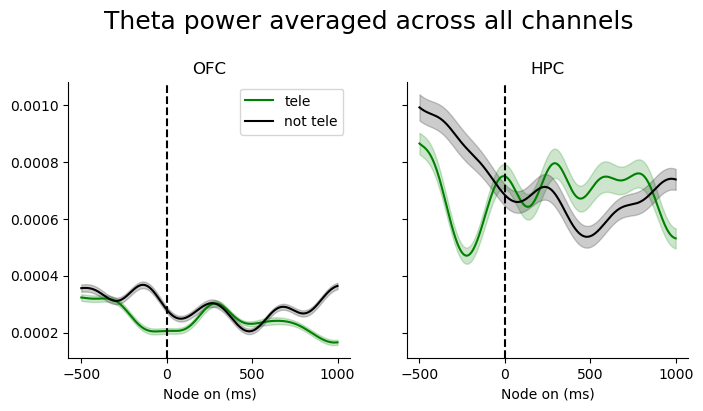

In [141]:
# tele vs non-tele
plt.close('all')
fig, axes = plt.subplots(1,2, figsize=(8,4),sharey=True)

plotting.plot_mean_sem(time,tele[:96,:],0,axes[0],'g','tele')
plotting.plot_mean_sem(time,non_tele[:96,:],0,axes[0],'k','not tele')
axes[0].set_title('OFC')
axes[0].axvline(0,color='k',ls='--')
axes[0].set_xlabel('Node on (ms)')

plotting.plot_mean_sem(time,tele[96:,:],0,axes[1],'g','')
plotting.plot_mean_sem(time,non_tele[96:,:],0,axes[1],'k','')
axes[1].set_title('HPC')
axes[1].axvline(0,color='k',ls='--')
axes[1].set_xlabel('Node on (ms)')

sns.despine()
fig.subplots_adjust(top=0.8)
axes[0].legend()
plt.suptitle('Theta power averaged across all channels',fontsize=18)
plt.savefig(f'D:/Theta/Session_{date}/hilbert_power/Session {date} theta power all channels average.png')

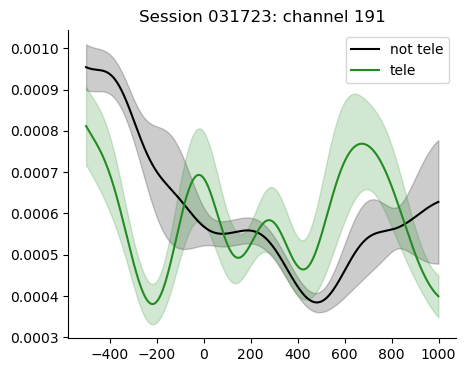

In [79]:
for channel in range(192):

    plt.close('all')
    fig, axes = plt.subplots(figsize=(5,4))
    
    trial_idx = ~df.use_tele.values
    plotting.plot_mean_sem(np.arange(window[0],window[-1]),results['power'][trial_idx,channel,:],0,axes,'k','not tele')
    
    trial_idx = df.use_tele.values
    plotting.plot_mean_sem(np.arange(window[0],window[-1]),results['power'][trial_idx,channel,:],0,axes,'forestgreen','tele')
    
    plt.legend()
    sns.despine()
    plt.title(f'Session {date}: channel {channel}')
    plt.savefig(f'D:/Theta/Session_{date}/hilbert_power/Session_{date}_channel{channel}_tele.png')

In [ ]:
# coherence
date = '031723'
epoch = 'node_on'
h5_path = f'D:/Spectrogram/Session{date}_{epoch}_wavelet.h5'

nav = nwbfile.intervals['node_on'].to_dataframe().query('trialerror==0')
nav = graph.append_use_tele(nav)

In [333]:
# find channel where its own power shows difference between tele vs non-tele
ch1 = 33
ch2 = 138
tele_PXY, tele_coh, non_tele_PXY, non_tele_coh = get_coherence(nav,ch1,ch2)

In [330]:
def get_coherence(df,ch1,ch2):
    
    with h5py.File(h5_path, 'r') as f:
        dset = f['wavelet_coeffs']  # access dataset by name
        sig1 = dset[ch1,:] 
        sig2 = dset[ch2,:] 
    
    n_trials = sig1.shape[0]
    SXX = np.zeros(sig1.shape)
    SYY = np.zeros(sig1.shape)
    SXY = np.zeros(sig1.shape,dtype=np.complex64)
    
    for trial in range(n_trials):
        xf = sig1[trial,:]
        yf = sig2[trial,:]
        SXX[trial,:], SYY[trial,:], SXY[trial,:] = LFP.cross_spectrum(xf,yf)
    
    first_step = df.step.values==0
    first_step_df = df[df.step==0]
    tele_idx = first_step_df.use_tele.values
    
    cross_spectrum = np.abs(SXY)**2
    
    idx = (df.step.values==0) & (df.use_tele.values)
    tele_PXY = cross_spectrum[idx,:,:].mean(axis=0)
    tele_coh = np.abs(SXY[idx,:].mean(axis=0)) / np.sqrt(SXX[idx,:].mean(axis=0)) / np.sqrt(SYY[idx,:].mean(axis=0))
    
    idx = (df.step.values==0) & (~df.use_tele.values)
    non_tele_PXY = cross_spectrum[idx,:,:].mean(axis=0)
    non_tele_coh = np.abs(SXY[idx,:].mean(axis=0)) / np.sqrt(SXX[idx,:].mean(axis=0)) / np.sqrt(SYY[idx,:].mean(axis=0))

    return tele_PXY, tele_coh, non_tele_PXY, non_tele_coh

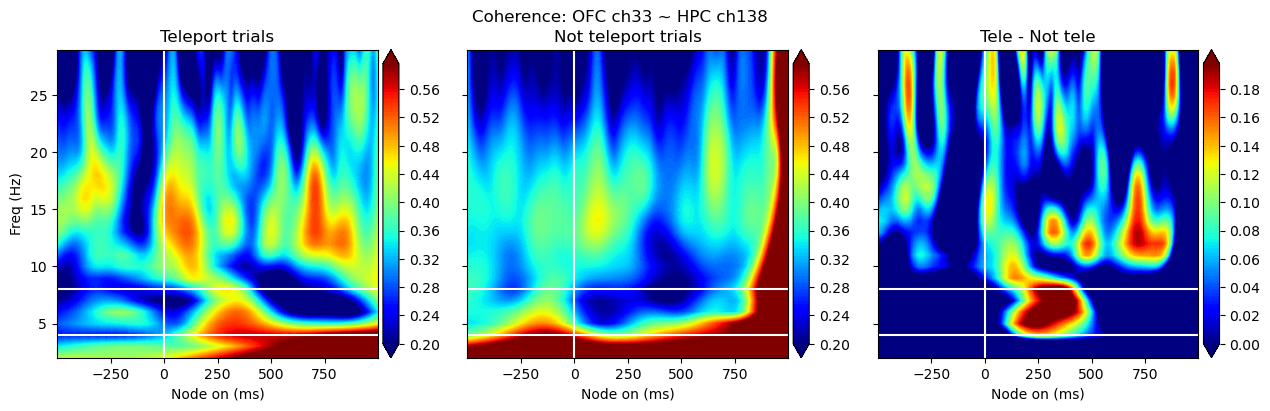

In [341]:
freqs = np.arange(2,30)
colormap = 'jet'

plt.close('all')
fig, axes = plt.subplots(1,3,figsize=(15,4),sharey=True)
ims = [[] for ii in range(3)]
freq_range = np.arange(2,30)

cmin = 0.2
cmax = 0.6

ims[0] = plotting.ogram(time,freqs,tele_coh,axes[0],cmin,cmax,colormap)
axes[0].set_title('Teleport trials')

ims[1] = plotting.ogram(time,freqs,non_tele_coh,axes[1],cmin,cmax,colormap)
axes[1].set_title('Not teleport trials')

diff = tele_coh-non_tele_coh
cmin=0
cmax = diff.max()*0.8
ims[2] = plotting.ogram(time,freqs,diff,axes[2],cmin,cmax,colormap)
axes[2].set_title('Tele - Not tele')

for ii in range(3):
    axes[ii].set_xlabel('Node on (ms)')
    axes[ii].axvline(0,color='w')
    axes[ii].axhline(4,color='w')
    axes[ii].axhline(8,color='w')
    axes[ii].set_xticks(np.arange(-250,1000,250))
    divider = make_axes_locatable(axes[ii])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(ims[ii], cax=cax)
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

axes[0].set_ylim(freq_range[0],freq_range[-1])
axes[0].set_ylabel('Freq (Hz)')

plt.suptitle(f'Coherence: OFC ch{ch1} ~ HPC ch{ch2}')
plt.savefig(f'D:/Spectrogram/Session_{date}_tele/cohererogram/Session {date} tele vs nontele OFC ch{ch1} HPC ch{ch2}.png')

In [43]:
date = '031723'

nwbfile = load_data.load_nwbfile('Bart',date) 
df = nwbfile.intervals['node_on'].to_dataframe()
df = df[df.trialerror==0]
df['graph_distance'] = np.clip(df['graph_distance'].values,0,3)
df = graph.append_use_tele(df)

In [4]:
choice_df = nwbfile.intervals['action_on'].to_dataframe().query('(trialerror==0) & (step==0)')

In [64]:
df['RT'] = choice_df.t_on - df.t_on

### Look at how theta evolves relative to RT

In [70]:
df['steps_saved'] = df['spatial_distance'] - df['graph_distance']

In [73]:
df[(df.steps_saved==0)&(df.use_tele)]

,start_time,stop_time,trial,step,trialerror,nsteps,start,target,block,blocktrialnumber,...,graph_distance,spatial_distance,window_size,nodes,timeseries,use_tele,0to15,15to0,RT,steps_saved
id,,,,,,,,,,,,,,,,,,,,,
51,249325.0,250325.0,20,0,0.0,14.0,6.0,8.0,3.0,7.0,...,3,3,500,"6,5,4,0,1,2,6,10,9,13,14,15,0,4,8","[(249325, 1000, neural pynwb.base.TimeSeries a...",True,False,True,708.0,0
415,990296.0,991296.0,158,0,0.0,4.0,2.0,14.0,22.0,8.0,...,3,3,500,"2,1,0,15,14","[(990296, 1000, neural pynwb.base.TimeSeries a...",True,True,False,208.0,0
687,1574373.0,1575373.0,267,0,0.0,5.0,15.0,7.0,37.0,6.0,...,2,2,500,"15,0,1,2,6,7","[(1574373, 1000, neural pynwb.base.TimeSeries ...",True,False,True,201.0,0
740,1686134.0,1687134.0,288,0,0.0,4.0,14.0,8.0,40.0,6.0,...,3,3,500,"14,15,0,4,8","[(1686134, 1000, neural pynwb.base.TimeSeries ...",True,False,True,183.0,0
836,1883214.0,1884214.0,324,0,0.0,4.0,2.0,14.0,45.0,7.0,...,3,3,500,"2,1,0,15,14","[(1883214, 1000, neural pynwb.base.TimeSeries ...",True,True,False,232.0,0
896,2021865.0,2022865.0,349,0,0.0,4.0,10.0,1.0,48.0,7.0,...,3,3,500,"10,14,15,0,1","[(2021865, 1000, neural pynwb.base.TimeSeries ...",True,False,True,207.0,0
1476,3540479.0,3541479.0,648,0,0.0,5.0,15.0,7.0,88.0,10.0,...,2,2,500,"15,0,1,2,3,7","[(3540479, 1000, neural pynwb.base.TimeSeries ...",True,False,True,233.0,0


<Axes: xlabel='RT', ylabel='Count'>

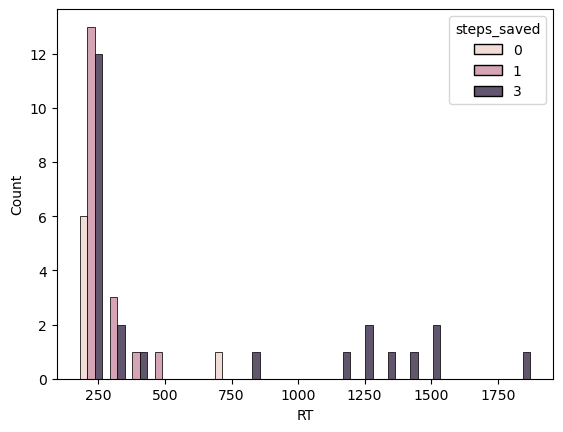

In [74]:
plt.close('all')
sns.histplot(data=df.query('use_tele'),x='RT',bins=20,hue='steps_saved',multiple='dodge')

In [102]:
trial=0
df.iloc[trial].RT

np.float64(218.0)

In [103]:
power_spec.shape

(192, 492, 28, 1500)

In [112]:
RT = df.iloc[trial].RT
power_spec[channel,trial,(freqs>3)&(freqs<9),:][:,500:int(500+RT)].mean()

np.float32(0.1542072)

In [119]:
# correlation between RT and theta power
# 1. between grid on and RT
# 2. 500ms before reaction
# 3. 500ms after reaction

theta_power = np.zeros((len(df),3))

for trial in range(len(df)):

    RT = df.iloc[trial].RT
    theta_power[trial,0] = power_spec[channel,trial,(freqs>3)&(freqs<9),:][:,500:int(500+RT)].mean()
    theta_power[trial,1] = power_spec[channel,trial,(freqs>3)&(freqs<9),:][:,int(RT):int(500+RT)].mean()
    theta_power[trial,2] = power_spec[channel,trial,(freqs>3)&(freqs<9),:][:,int(250+RT):int(750+RT)].mean()
    

C:\Users\Admin\AppData\Local\Temp\ipykernel_33276\2362339630.py:13: RuntimeWarning: Mean of empty slice.
  theta_power[trial,2] = power_spec[channel,trial,(freqs>3)&(freqs<9),:][:,int(250+RT):int(750+RT)].mean()
C:\Users\Admin\anaconda3\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Admin\AppData\Local\Temp\ipykernel_33276\2362339630.py:13: RuntimeWarning: Mean of empty slice.
  theta_power[trial,2] = power_spec[channel,trial,(freqs>3)&(freqs<9),:][:,int(250+RT):int(750+RT)].mean()
C:\Users\Admin\anaconda3\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Admin\AppData\Local\Temp\ipykernel_33276\2362339630.py:13: RuntimeWarning: Mean of empty slice.
  theta_power[trial,2] = power_spec[channel,trial,(freqs>3)&(freqs<9),:][:,int(250+RT):int(750+RT)].mean()
C:\Users\Admin\anaconda3\Lib\site-packages

In [134]:
def plot_sem(time, trace, ax, label, color):

    mean_trace = trace.mean(axis=0)
    sem_trace = trace.std(axis=0)/np.sqrt(trace.shape[0])
    ax.plot(time, mean_trace, color=color, label=label)
    ax.fill_between(time,
                    mean_trace - sem_trace,
                    mean_trace + sem_trace,
                    color=color,
                    alpha=0.3)

In [ ]:
# this is the power averaged from wavelet analysis
# double check with instantaneous power from hilber transformation

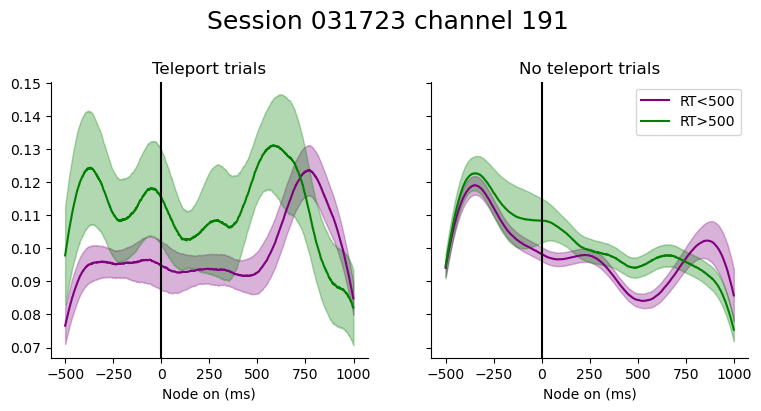

In [156]:
time=np.arange(-500,1000)

for channel in range(192):
    
    plt.close('all')
    fig, axes = plt.subplots(1,2,figsize=(9,4),sharey=True)
    
    trial_idx = (df.use_tele.values) & (df.RT<500)
    plot_sem(time,power_spec[channel,trial_idx,:,:][:,(freqs>3)&(freqs<9),:].mean(axis=1),axes[0],'RT<500','purple')
    
    trial_idx = (df.use_tele.values) & (df.RT>500)
    plot_sem(time,power_spec[channel,trial_idx,:,:][:,(freqs>3)&(freqs<9),:].mean(axis=1),axes[0],'RT>500','green')
    
    axes[0].set_title('Teleport trials')
    axes[0].set_xlabel('Node on (ms)')
    axes[0].axvline(0,color='k')
    
    
    trial_idx = (~df.use_tele.values) & (df.RT<500)
    plot_sem(time,power_spec[channel,trial_idx,:,:][:,(freqs>3)&(freqs<9),:].mean(axis=1),axes[1],'RT<500','purple')
    
    trial_idx = (~df.use_tele.values) & (df.RT>500)
    plot_sem(time,power_spec[channel,trial_idx,:,:][:,(freqs>3)&(freqs<9),:].mean(axis=1),axes[1],'RT>500','green')
    
    axes[1].set_title('No teleport trials')
    axes[1].set_xlabel('Node on (ms)')
    axes[1].axvline(0,color='k')

    fig.subplots_adjust(top=0.8)
    plt.suptitle(f'Session {date} channel {channel}',fontsize=18)
    plt.legend()
    sns.despine()
    plt.savefig(f'D:/Theta/Session_{date}/Session {date} channel {channel}, RT and theta power.png')

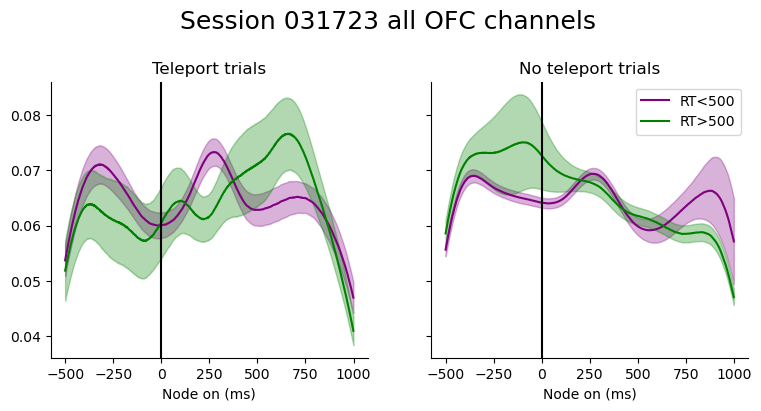

In [165]:
# average cross all channels on a probe

time=np.arange(-500,1000)


plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(9,4),sharey=True)

trial_idx = (df.use_tele.values) & (df.RT<500)
plot_sem(time,power_spec[:96,trial_idx,:,:][:,:,(freqs>3)&(freqs<9),:].mean(axis=(0,2)),axes[0],'RT<500','purple')

trial_idx = (df.use_tele.values) & (df.RT>500)
plot_sem(time,power_spec[:96,trial_idx,:,:][:,:,(freqs>3)&(freqs<9),:].mean(axis=(0,2)),axes[0],'RT>500','green')

axes[0].set_title('Teleport trials')
axes[0].set_xlabel('Node on (ms)')
axes[0].axvline(0,color='k')


trial_idx = (~df.use_tele.values) & (df.RT<500)
plot_sem(time,power_spec[:96,trial_idx,:,:][:,:,(freqs>3)&(freqs<9),:].mean(axis=(0,2)),axes[1],'RT<500','purple')

trial_idx = (~df.use_tele.values) & (df.RT>500)
plot_sem(time,power_spec[:96,trial_idx,:,:][:,:,(freqs>3)&(freqs<9),:].mean(axis=(0,2)),axes[1],'RT>500','green')

axes[1].set_title('No teleport trials')
axes[1].set_xlabel('Node on (ms)')
axes[1].axvline(0,color='k')

fig.subplots_adjust(top=0.8)
plt.suptitle(f'Session {date} all OFC channels',fontsize=18)
plt.legend()
sns.despine()
plt.savefig(f'D:/Theta/Session_{date}/Session {date} all OFC channels, RT and theta power.png')

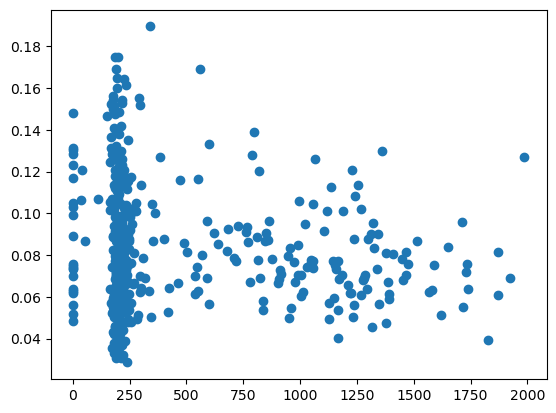

In [120]:
plt.close('all')
plt.scatter(df.RT.values,theta_power[:,0])

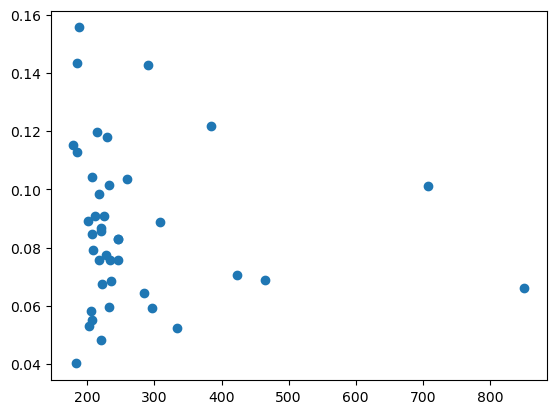

In [123]:
plt.close('all')
idx = (df.use_tele.values)&(df.RT.values<1000)
plt.scatter(df.RT.values[idx],theta_power[idx,2])

In [167]:
timestamps, lfpData = load_data.load_LFP(date)

In [171]:
# load processed wavelet frequency

ch1 = 45
ch2 = 127
epoch = 'node_on'
h5_path = f'D:/Spectrogram/Session{date}_{epoch}_wavelet.h5'

with h5py.File(h5_path, 'r') as f:
    dset = f['wavelet_coeffs']
    xfs = dset[ch1]
    yfs = dset[ch2]
    

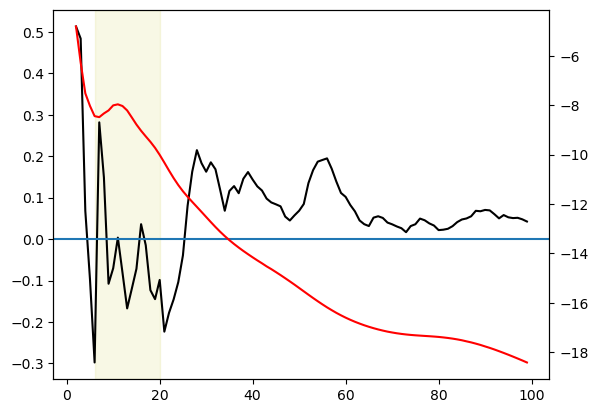

In [168]:
# coherogram

ch1 = 45
ch2 = 127
time = np.arange(10000)
freq_range = np.arange(2,100)  

sig1 = LFP.notchfilter(lfpData[time,ch1])
sig2 = LFP.notchfilter(lfpData[time,ch2])

freqs, xf = LFP.wavelet(sig1, freq_range)
freqs, yf = LFP.wavelet(sig2, freq_range)


SXX = np.real(xf*np.conj(xf))
SYY = np.real(yf*np.conj(yf))
SXY = xf*np.conj(yf)  
cross_power = np.abs(SXY)**2
phase = np.angle(SXY)

plt.close('all')
fig, ax = plt.subplots()
ax.plot(freqs,phase.mean(axis=1),color='k')

ax2 = ax.twinx()
ax2.plot(freqs,np.log(cross_power.mean(axis=1)),color='r')
ax.axhline(0)
ax.axvspan(6,20,color='y',alpha=0.1)

Text(0.5, 1.0, 'Channel 0')

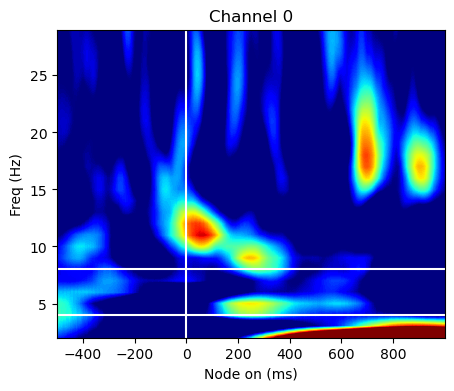

In [97]:
channel = 0
trial_idx = df.use_tele.values & (df.RT.values<250)

time = np.arange(-500,1000)
freqs = np.arange(2,30)
cmin = 0
cmax = 0.02
colormap = 'jet'

node_on_power = power_spec[channel,df.use_tele.values & (df.RT.values<250),:,:].mean(axis=0)
non_tele = power_spec[channel,(~df.use_tele.values) & (df.RT.values<250),:].mean(axis=0)

plt.close('all')
fig, axes = plt.subplots(1,1,figsize=(5,4),sharey=True)

plotting.ogram(time,freqs,node_on_power-non_tele,axes,cmin,cmax,colormap)
plt.axhline(4,color='w')
plt.axhline(8,color='w')
plt.axvline(0,color='w')
plt.ylim(freqs[0],freqs[-1])
plt.xlabel('Node on (ms)')
plt.ylabel('Freq (Hz)')
plt.title(f'Channel {channel}')
# plt.savefig(f'D:/Spectrogram/Session_{date}_channel{channel}.png')

Text(0.5, 1.0, 'Channel 0')

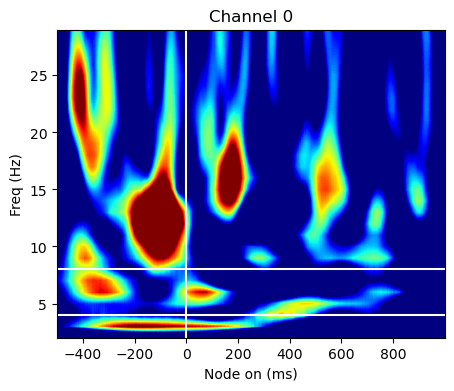

In [99]:
channel = 0

time = np.arange(-500,1000)
freqs = np.arange(2,30)
cmin = 0
cmax = 0.02
colormap = 'jet'

node_on_power = power_spec[channel,df.use_tele.values & (df.RT.values>250) & (df.RT.values<500),:,:].mean(axis=0)
non_tele = power_spec[channel,(~df.use_tele.values) & (df.RT.values>250) & (df.RT.values<500),:].mean(axis=0)

plt.close('all')
fig, axes = plt.subplots(1,1,figsize=(5,4),sharey=True)

plotting.ogram(time,freqs,node_on_power-non_tele,axes,cmin,cmax,colormap)
plt.axhline(4,color='w')
plt.axhline(8,color='w')
plt.axvline(0,color='w')
plt.ylim(freqs[0],freqs[-1])
plt.xlabel('Node on (ms)')
plt.ylabel('Freq (Hz)')
plt.title(f'Channel {channel}')
# plt.savefig(f'D:/Spectrogram/Session_{date}_channel{channel}.png')

Text(0.5, 1.0, 'Channel 0')

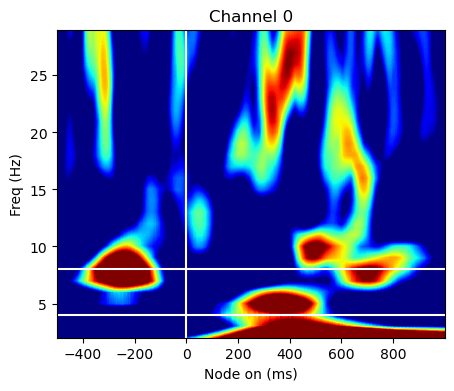

In [101]:
channel = 0

time = np.arange(-500,1000)
freqs = np.arange(2,30)
cmin = 0
cmax = 0.02
colormap = 'jet'

node_on_power = power_spec[channel,df.use_tele.values & (df.RT.values>1000) & (df.RT.values<1750),:,:].mean(axis=0)
non_tele = power_spec[channel,(~df.use_tele.values) & (df.RT.values>1000) & (df.RT.values<1750),:].mean(axis=0)

plt.close('all')
fig, axes = plt.subplots(1,1,figsize=(5,4),sharey=True)

plotting.ogram(time,freqs,node_on_power-non_tele,axes,cmin,cmax,colormap)
plt.axhline(4,color='w')
plt.axhline(8,color='w')
plt.axvline(0,color='w')
plt.ylim(freqs[0],freqs[-1])
plt.xlabel('Node on (ms)')
plt.ylabel('Freq (Hz)')
plt.title(f'Channel {channel}')
# plt.savefig(f'D:/Spectrogram/Session_{date}_channel{channel}.png')

In [ ]:
# find when the animal is at the teleport, theta aligned to action onset
# add a column to action_df, if before teleport 1; if after teleport 0
idx = np.isin(df.node.values,[0,15]) & df.tele_use.values
tele_actions = df[idx]
for trial in tele_actions.trial.unique():
    nodes = tele_actions.